# Efficient Flood TIFF Viewer

This notebook visualizes one official flood depth TIFF efficiently, even when the original raster is very large.

It uses a two-stage strategy:
- first, a coarse pass over the whole raster to find where flooded pixels are
- second, a more detailed local crop around the flood only

This is much more efficient and much easier to read than trying to display the full raster at once.


In [10]:
from dataclasses import dataclass
from pathlib import Path

from affine import Affine
import folium
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pyproj import Transformer
from rasterio.enums import Resampling
from rasterio.windows import Window


In [15]:
# Change only this path when you want to inspect another TIFF.
TIF_PATH = Path(
    r"d:\M2_MoSEF\DataCollection\data/JRC_flood_depth_maps/2024/"
    "WD_MERGE_2024-12-23---2025-01-06_duration_14_days_cluster_321_A0_000004_A_000004_lat_04826_lon_-0303_size_0074.tif"
)

# Fast whole-raster scan to find the flood location.
COARSE_MAX_SIZE = 1200

# Detailed local crop after the flood zone has been located.
DETAIL_MAX_SIZE = 1800
SOURCE_PADDING_PIXELS = 600

# Flood masking rules.
THRESHOLD_CM = 0.0
MASK_VALUES = (9999,)

# Display tuning.
UPPER_QUANTILE = 0.995
COLORMAP = "turbo"
TILES = "CartoDB positron"

# Rendering mode:
# - "auto": exact native 20m cells for sparse floods, raster overlay otherwise
# - "pixels": exact native 20m cells as polygons
# - "raster": raster image overlay
MAP_MODE = "auto"
PIXEL_MODE_MAX_CELLS = 4000
EXACT_NATIVE_PIXEL_LIMIT = 12000

# Optional HTML export.
SAVE_HTML = None  # Example: Path("sandbox/flood_preview.html")

assert TIF_PATH.exists(), f"File not found: {TIF_PATH}"
TIF_PATH


WindowsPath('d:/M2_MoSEF/DataCollection/data/JRC_flood_depth_maps/2024/WD_MERGE_2024-12-23---2025-01-06_duration_14_days_cluster_321_A0_000004_A_000004_lat_04826_lon_-0303_size_0074.tif')

In [16]:
@dataclass
class FloodPreview:
    tif_path: Path
    values: np.ma.MaskedArray
    display_transform: Affine
    bounds_latlon: list[list[float]]
    full_bounds_latlon: list[list[float]]
    coarse_shape: tuple[int, int]
    display_shape: tuple[int, int]
    source_window_shape: tuple[int, int]
    src_height: int
    src_width: int
    crs: str
    nodata: float | None
    vmin: float
    vmax: float
    active_pixel_count: int
    source_window: tuple[int, int, int, int]
    coarse_active_pixels: list[tuple[int, int]]


def xy_bounds_to_latlon(left, bottom, right, top, src_crs, samples_per_edge=41):
    xs = np.concatenate([
        np.linspace(left, right, samples_per_edge),
        np.full(samples_per_edge, right),
        np.linspace(right, left, samples_per_edge),
        np.full(samples_per_edge, left),
    ])
    ys = np.concatenate([
        np.full(samples_per_edge, bottom),
        np.linspace(bottom, top, samples_per_edge),
        np.full(samples_per_edge, top),
        np.linspace(top, bottom, samples_per_edge),
    ])
    transformer = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True)
    lons, lats = transformer.transform(xs, ys)
    return [[float(np.min(lats)), float(np.min(lons))], [float(np.max(lats)), float(np.max(lons))]]


def raster_bounds_to_latlon(src):
    left, bottom, right, top = src.bounds
    return xy_bounds_to_latlon(left, bottom, right, top, src.crs)


def build_mask(data, nodata, threshold_cm=0.0, mask_values=(9999,)):
    mask = np.zeros(data.shape, dtype=bool)
    if nodata is not None:
        mask |= data == nodata
    for value in mask_values:
        mask |= data == value
    mask |= data <= threshold_cm
    return mask


def find_source_window(src, coarse_max_size=1200, threshold_cm=0.0, mask_values=(9999,), padding_pixels=600):
    scale = min(coarse_max_size / max(src.height, src.width), 1.0)
    coarse_h = max(1, int(round(src.height * scale)))
    coarse_w = max(1, int(round(src.width * scale)))

    coarse_data = src.read(
        1,
        out_shape=(coarse_h, coarse_w),
        resampling=Resampling.nearest,
        masked=False,
    ).astype(np.float32, copy=False)
    coarse_mask = build_mask(coarse_data, src.nodata, threshold_cm=threshold_cm, mask_values=mask_values)
    active_rows, active_cols = np.where(~coarse_mask)
    if active_rows.size == 0:
        raise ValueError("No positive flood pixels remain after masking.")

    row_scale = src.height / coarse_h
    col_scale = src.width / coarse_w

    src_row_min = max(int(np.floor(active_rows.min() * row_scale)) - padding_pixels, 0)
    src_row_max = min(int(np.ceil((active_rows.max() + 1) * row_scale)) + padding_pixels, src.height)
    src_col_min = max(int(np.floor(active_cols.min() * col_scale)) - padding_pixels, 0)
    src_col_max = min(int(np.ceil((active_cols.max() + 1) * col_scale)) + padding_pixels, src.width)

    window = Window(
        col_off=src_col_min,
        row_off=src_row_min,
        width=src_col_max - src_col_min,
        height=src_row_max - src_row_min,
    )
    coarse_active_pixels = list(zip(active_rows.astype(int).tolist(), active_cols.astype(int).tolist()))
    return window, (coarse_h, coarse_w), coarse_active_pixels


def read_window_preview(src, window, detail_max_size=1800, threshold_cm=0.0, mask_values=(9999,), upper_quantile=0.995):
    win_h = int(window.height)
    win_w = int(window.width)
    scale = min(detail_max_size / max(win_h, win_w), 1.0)
    out_h = max(1, int(round(win_h * scale)))
    out_w = max(1, int(round(win_w * scale)))

    data = src.read(
        1,
        window=window,
        out_shape=(out_h, out_w),
        resampling=Resampling.nearest,
        masked=False,
    ).astype(np.float32, copy=False)

    mask = build_mask(data, src.nodata, threshold_cm=threshold_cm, mask_values=mask_values)
    masked = np.ma.masked_array(data, mask=mask)
    valid = masked.compressed()
    if valid.size == 0:
        raise ValueError("No positive flood pixels remain inside the detailed crop.")

    vmin = float(valid.min())
    vmax = float(np.quantile(valid, upper_quantile))
    if vmax <= vmin:
        vmax = float(valid.max())

    window_transform = src.window_transform(window)
    display_transform = window_transform * Affine.scale(win_w / out_w, win_h / out_h)

    left, top = display_transform * (0, 0)
    right, bottom = display_transform * (out_w, out_h)
    bounds_latlon = xy_bounds_to_latlon(
        left=min(left, right),
        bottom=min(bottom, top),
        right=max(left, right),
        top=max(bottom, top),
        src_crs=src.crs,
    )

    return masked, display_transform, bounds_latlon, vmin, vmax


def read_flood_preview(
    tif_path,
    coarse_max_size=1200,
    detail_max_size=1800,
    threshold_cm=0.0,
    mask_values=(9999,),
    source_padding_pixels=600,
    upper_quantile=0.995,
):
    tif_path = Path(tif_path)
    with rasterio.open(tif_path) as src:
        full_bounds_latlon = raster_bounds_to_latlon(src)
        window, coarse_shape, coarse_active_pixels = find_source_window(
            src,
            coarse_max_size=coarse_max_size,
            threshold_cm=threshold_cm,
            mask_values=mask_values,
            padding_pixels=source_padding_pixels,
        )
        masked, display_transform, bounds_latlon, vmin, vmax = read_window_preview(
            src,
            window,
            detail_max_size=detail_max_size,
            threshold_cm=threshold_cm,
            mask_values=mask_values,
            upper_quantile=upper_quantile,
        )

        return FloodPreview(
            tif_path=tif_path,
            values=masked,
            display_transform=display_transform,
            bounds_latlon=bounds_latlon,
            full_bounds_latlon=full_bounds_latlon,
            coarse_shape=coarse_shape,
            display_shape=masked.shape,
            source_window_shape=(int(window.height), int(window.width)),
            src_height=src.height,
            src_width=src.width,
            crs=str(src.crs),
            nodata=src.nodata,
            vmin=vmin,
            vmax=vmax,
            active_pixel_count=int(masked.count()),
            source_window=(int(window.row_off), int(window.col_off), int(window.height), int(window.width)),
            coarse_active_pixels=coarse_active_pixels,
        )


def preview_to_rgba(preview, cmap_name="turbo"):
    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.Normalize(vmin=preview.vmin, vmax=preview.vmax, clip=True)
    filled = preview.values.filled(preview.vmin)
    normalized = norm(filled)
    rgba = cmap(normalized)
    alpha = 0.55 + np.clip(normalized, 0.0, 1.0) * 0.40
    rgba[..., 3] = np.where(preview.values.mask, 0.0, alpha)
    return (rgba * 255).astype(np.uint8)


def show_static_preview(preview, cmap_name="turbo"):
    plt.figure(figsize=(9, 9))
    plt.gca().set_facecolor("black")
    plt.imshow(preview.values, cmap=cmap_name, vmin=preview.vmin, vmax=preview.vmax)
    plt.title(preview.tif_path.name)
    plt.axis("off")
    cbar = plt.colorbar(shrink=0.75)
    cbar.set_label("Flood depth (cm)")
    plt.show()


def extract_exact_native_pixels(preview, threshold_cm=0.0, mask_values=(9999,), max_cells=12000):
    row_scale = preview.src_height / preview.coarse_shape[0]
    col_scale = preview.src_width / preview.coarse_shape[1]
    exact_pixels = []
    with rasterio.open(preview.tif_path) as src:
        for coarse_row, coarse_col in preview.coarse_active_pixels:
            src_row_min = int(np.floor(coarse_row * row_scale))
            src_row_max = int(np.ceil((coarse_row + 1) * row_scale))
            src_col_min = int(np.floor(coarse_col * col_scale))
            src_col_max = int(np.ceil((coarse_col + 1) * col_scale))
            window = Window(
                col_off=src_col_min,
                row_off=src_row_min,
                width=max(1, src_col_max - src_col_min),
                height=max(1, src_row_max - src_row_min),
            )
            data = src.read(1, window=window, masked=False).astype(np.float32, copy=False)
            mask = build_mask(data, src.nodata, threshold_cm=threshold_cm, mask_values=mask_values)
            active_rows, active_cols = np.where(~mask)
            if len(exact_pixels) + len(active_rows) > max_cells:
                return None
            block_transform = src.window_transform(window)
            for row, col in zip(active_rows, active_cols):
                exact_pixels.append((block_transform, int(row), int(col), float(data[row, col])))
    return exact_pixels


def add_pixel_polygons(flood_map, preview, cmap_name="turbo", threshold_cm=0.0, mask_values=(9999,), max_cells=12000):
    exact_pixels = extract_exact_native_pixels(
        preview,
        threshold_cm=threshold_cm,
        mask_values=mask_values,
        max_cells=max_cells,
    )
    if exact_pixels is None:
        return False

    transformer = Transformer.from_crs(preview.crs, "EPSG:4326", always_xy=True)
    cmap = mpl.colormaps[cmap_name]
    norm = mpl.colors.Normalize(vmin=preview.vmin, vmax=preview.vmax, clip=True)

    for block_transform, row, col, value in exact_pixels:
        left, top = block_transform * (col, row)
        right, bottom = block_transform * (col + 1, row + 1)
        corners_x = [left, right, right, left]
        corners_y = [top, top, bottom, bottom]
        lons, lats = transformer.transform(corners_x, corners_y)
        polygon = list(zip(lats, lons))
        color = mpl.colors.to_hex(cmap(norm(value)))

        folium.Polygon(
            locations=polygon,
            color="#111111",
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.9,
            tooltip=f"Depth: {value:.1f} cm",
        ).add_to(flood_map)
    return True


def build_folium_map(preview, cmap_name="turbo", tiles="CartoDB positron", mode="auto", pixel_mode_max_cells=4000, threshold_cm=0.0, mask_values=(9999,), exact_native_pixel_limit=12000):
    lat_center = (preview.bounds_latlon[0][0] + preview.bounds_latlon[1][0]) / 2
    lon_center = (preview.bounds_latlon[0][1] + preview.bounds_latlon[1][1]) / 2
    flood_map = folium.Map(location=[lat_center, lon_center], zoom_start=9, tiles=tiles)

    chosen_mode = mode
    if mode == "auto":
        chosen_mode = "pixels" if preview.active_pixel_count <= pixel_mode_max_cells else "raster"

    if chosen_mode == "pixels":
        pixels_added = add_pixel_polygons(
            flood_map,
            preview,
            cmap_name=cmap_name,
            threshold_cm=threshold_cm,
            mask_values=mask_values,
            max_cells=exact_native_pixel_limit,
        )
        if not pixels_added:
            chosen_mode = "raster_fallback"
    if chosen_mode != "pixels":
        rgba = preview_to_rgba(preview, cmap_name=cmap_name)
        folium.raster_layers.ImageOverlay(
            image=rgba,
            bounds=preview.bounds_latlon,
            opacity=1.0,
            name="Flood depth preview",
            interactive=True,
            cross_origin=False,
        ).add_to(flood_map)

    folium.LayerControl(collapsed=False).add_to(flood_map)
    flood_map.fit_bounds(preview.bounds_latlon)

    caption = (
        f"<div style='position: fixed; bottom: 18px; left: 18px; z-index: 9999; "
        f"background: white; padding: 10px 12px; border: 1px solid #999; font-size: 12px;'>"
        f"<b>{preview.tif_path.name}</b><br>"
        f"Render mode: {chosen_mode}<br>"
        f"Active preview pixels: {preview.active_pixel_count:,}<br>"
        f"Coarse active pixels: {len(preview.coarse_active_pixels):,}<br>"
        f"Detailed crop preview: {preview.display_shape[1]} x {preview.display_shape[0]} px<br>"
        f"Detailed source window: {preview.source_window_shape[1]} x {preview.source_window_shape[0]} px<br>"
        f"Full raster: {preview.src_width} x {preview.src_height} px<br>"
        f"Depth range shown: {preview.vmin:.1f} to {preview.vmax:.1f} cm"
        f"</div>"
    )
    flood_map.get_root().html.add_child(folium.Element(caption))
    return flood_map


{'file': 'd:\\M2_MoSEF\\DataCollection\\data\\JRC_flood_depth_maps\\2024\\WD_MERGE_2024-12-23---2025-01-06_duration_14_days_cluster_321_A0_000004_A_000004_lat_04826_lon_-0303_size_0074.tif', 'source_shape': (15000, 15000), 'coarse_shape': (1200, 1200), 'source_window_shape': (10976, 3250), 'display_shape': (1800, 533), 'active_pixel_count': 335, 'source_window': (2537, 11750, 10976, 3250), 'bounds_latlon': [[47.03230493599293, -3.9263162998676546], [49.05758538706974, -2.0778611805829708]], 'full_bounds_latlon': [[45.999164588226726, -7.123506388832566], [49.4760283348477, -1.9460721527052005]], 'display_range_cm': (10.0, 135.99)}


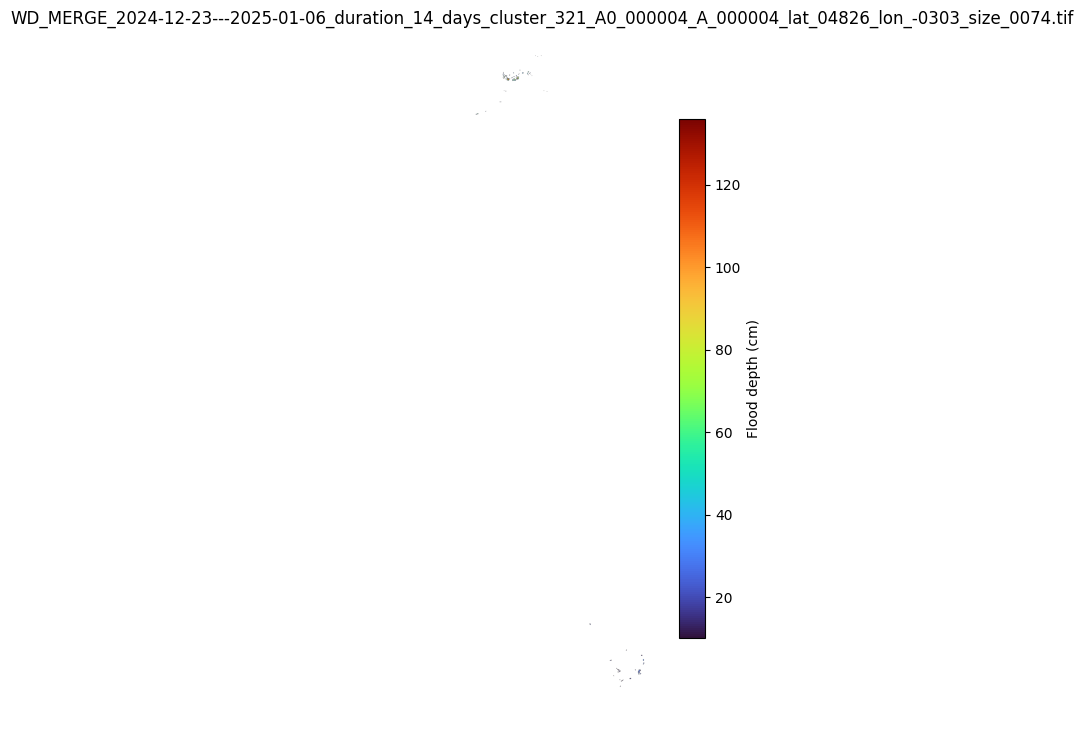

In [17]:
preview = read_flood_preview(
    TIF_PATH,
    coarse_max_size=COARSE_MAX_SIZE,
    detail_max_size=DETAIL_MAX_SIZE,
    threshold_cm=THRESHOLD_CM,
    mask_values=MASK_VALUES,
    source_padding_pixels=SOURCE_PADDING_PIXELS,
    upper_quantile=UPPER_QUANTILE,
)

print({
    "file": str(preview.tif_path),
    "source_shape": (preview.src_height, preview.src_width),
    "coarse_shape": preview.coarse_shape,
    "source_window_shape": preview.source_window_shape,
    "display_shape": preview.display_shape,
    "active_pixel_count": preview.active_pixel_count,
    "source_window": preview.source_window,
    "bounds_latlon": preview.bounds_latlon,
    "full_bounds_latlon": preview.full_bounds_latlon,
    "display_range_cm": (round(preview.vmin, 2), round(preview.vmax, 2)),
})

show_static_preview(preview, cmap_name=COLORMAP)

flood_map = build_folium_map(
    preview,
    cmap_name=COLORMAP,
    tiles=TILES,
    mode=MAP_MODE,
    pixel_mode_max_cells=PIXEL_MODE_MAX_CELLS,
    threshold_cm=THRESHOLD_CM,
    mask_values=MASK_VALUES,
    exact_native_pixel_limit=EXACT_NATIVE_PIXEL_LIMIT,
)

if SAVE_HTML is not None:
    SAVE_HTML = Path(SAVE_HTML)
    SAVE_HTML.parent.mkdir(parents=True, exist_ok=True)
    flood_map.save(str(SAVE_HTML))
    print(f"Saved HTML map to: {SAVE_HTML}")

flood_map


## Notes

- `MAP_MODE = "pixels"` is best for sparse floods because each visible cell is drawn individually on the map.
- `MAP_MODE = "raster"` is better for broad floods with many cells.
- If a few cells still appear offshore after this detailed local crop, that is much more likely to come from the source raster itself than from the notebook display.
- Increase `SOURCE_PADDING_PIXELS` if you want more context around the flood.
- Increase `DETAIL_MAX_SIZE` if you want a more detailed local crop.
